## Student Performance Indicator

### Life cycle of ML Project

##### . Understanding the problem statement
##### . Data collection
##### . Data checks to perform
##### . EDA
##### . Data pre-processing
##### . Model training
##### . Choose best model

### Importing some libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the dataset 

In [4]:
df=pd.read_csv('data/stud.csv')

### Show top 5 records

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape of dataset

In [6]:
df.shape

(1000, 8)

### Check missing values

In [7]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### There are no missing values in dataset

### Check the duplicates

In [8]:
df.duplicated().sum()

0

##### There are no duplicates in dataset

### Check data types

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Checking the no. of unique values of each column

In [11]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### Check statistics of dataset 

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
print("Categories in 'gender' variable : ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable : ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable : ",end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable : ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable : ",end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable :  ['female' 'male']
Categories in 'race/ethnicity' variable :  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable :  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable :  ['standard' 'free/reduced']
Categories in 'test preparation course' variable :  ['none' 'completed']


In [19]:
num_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
cat_feature = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numerical features : {}".format(len(num_feature),num_feature))
print("We have {} categorical features : {}".format(len(cat_feature),cat_feature))


We have 3 numerical features : ['math score', 'reading score', 'writing score']
We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### Adding columns for "Total score" and "Average"

In [20]:
df['Total score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average score'] = df['Total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total score,Average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [25]:
reading_full = df[df['reading score'] == 100]['Average score'].count()
writing_full = df[df['writing score'] == 100]['Average score'].count()
math_full = df[df['math score'] == 100]['Average score'].count()

print("no. of students with full marks in Maths :",{math_full})
print("no. of students with full marks in reading :",{reading_full})
print("no. of students with full marks in writing :",{writing_full})

no. of students with full marks in Maths : {7}
no. of students with full marks in reading : {17}
no. of students with full marks in writing : {14}


In [26]:
reading_less_20 = df[df['reading score'] <= 20]['Average score'].count()
writing_less_20 = df[df['writing score'] <= 20]['Average score'].count()
math_less_20 = df[df['math score'] <= 20]['Average score'].count()

print("no. of students with less than 20 marks in Maths :",{math_less_20})
print("no. of students with less than 20 marks in reading :",{reading_less_20})
print("no. of students with less than 20 marks in writing :",{writing_less_20})

no. of students with less than 20 marks in Maths : {4}
no. of students with less than 20 marks in reading : {1}
no. of students with less than 20 marks in writing : {3}


### Histogram and KDE

<Axes: xlabel='Average score', ylabel='Count'>

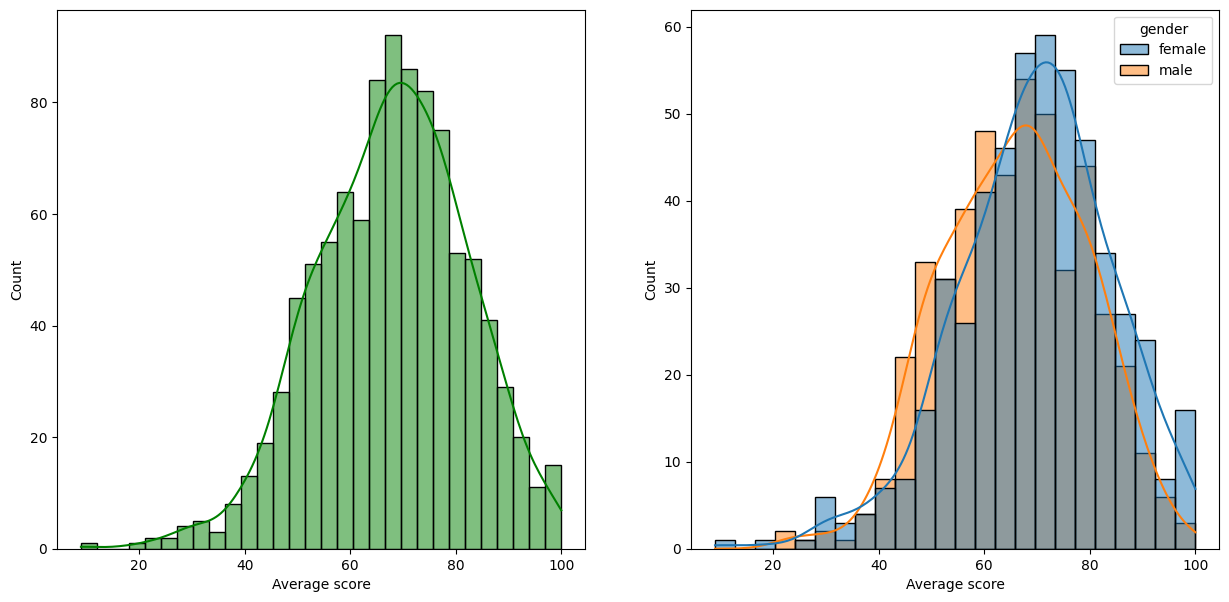

In [28]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average score',kde=True,hue='gender')